<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/Aberrations/SphericalAberration_Lens_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-- parameters --
focal length= 69.93  mm; 
 p factor= -0.9801980198019804 ; 
 q factor= 0.23076923076923078 ;
C40 =  -1.179456666594778e-05  1/mm^3; 
 Max_TSA= -0.49982569227722756  mm; 
 Max_LSA= -6.418410052998165  mm


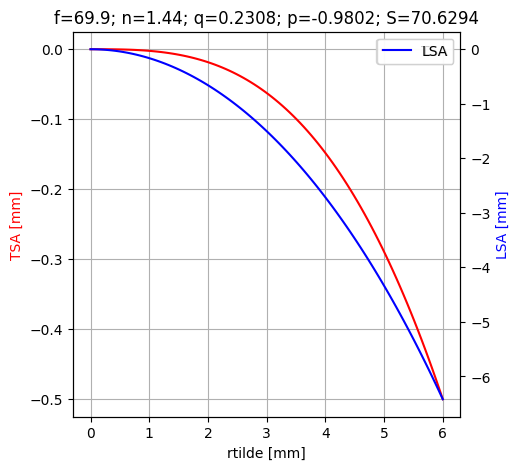

In [2]:
import matplotlib.pyplot as plt
import numpy as np

#####   spherical aberration
#####   19 MArch 2025
#####    G. Chirico
### here the compèutation of the spherical Aberration of a thin lens, Eq. 4.88 Klein-Optics

def C40(f,n,p,q):
    ### p is the position factor
    ### q is the form factore
    ### f is the focal length
    ### Spherical aberration coefficient

    A   = -1/(3*f**3*n*(n-1))
    a0  = (n+2)/(n-1)*q**2
    a1  = 4*(n+1)*q*p
    a2  = (3*n+2)*(n-1)*p**2
    a4  = n**3 /(n-1)

    return A*(a0+a1+a2+a4)
############## ######
def TSA(C40,Lprime,rtilde,RI):
    return 4*C40*Lprime *rtilde**3/RI
############  exact equation
def LSA(tsa,L,x):
    return L*tsa/(tsa+x)
######################    main

pupil   = 6  # mm
R1      = 50  ## mm
R2      = -1.6*R1    ### this is a symmetric lens
RI      = 1.44

f       = 1/((RI-1)*(1/R1-1/R2))

q       = (R2+R1)/(R2-R1)

Sprime  = 1.01*f ## mm
p       = 1 - 2*f/Sprime

Csph    = C40(f,RI,p,q)
tsa     = TSA(Csph,Sprime,pupil,RI)
lsa     = LSA(tsa,Sprime,pupil)
print ('-- parameters --')
print ('focal length=',round(f,3),' mm; \n p factor=',p,'; \n q factor=',q,';')
print ('C40 = ',Csph,' 1/mm^3; \n Max_TSA=',tsa,' mm; \n Max_LSA=',lsa,' mm')

x       = np.linspace(pupil*0.00001,pupil,100)
F,A     = plt.subplots(figsize=(5,5))

yt       = TSA(Csph,Sprime,x,RI)
yl       = LSA(yt,Sprime,x)

A.plot(x,yt,label='TSA',c='red')
A.set_ylabel('TSA [mm]',c='red')
A.legend()
plt.grid()
A1  = A.twinx()
A1.plot(x,yl,label = 'LSA',c='blue')


A1.set_ylabel('LSA [mm]',c='blue')

A.set_xlabel('rtilde [mm]',c='black')
titolo  = 'f=' + str(round(f,1))+'; n='+str(RI)+'; q='+str(round(q,4))+'; p='+str(round(p,4)) +'; S='+str(round(Sprime,4))
plt.title(titolo)

plt.legend()

comment on the computation.
We use Eq.4.88 of Klein.
The form factor q=(R+R')/(R'-R)
the position factor is p=1-2f/S'
rtidle is the radial coordinate on the pupil plane.
The output is the C40 coefficient, which is printed and the trend of the TSA and LSA as a function of the position of the ray on the pupil.
In the followinmg we plot the C40 factor for specific value opf the position factor as a function of the q factor, the form factor of the lens.

Text(0.5, 1.0, ' focal length =50 [mm]')

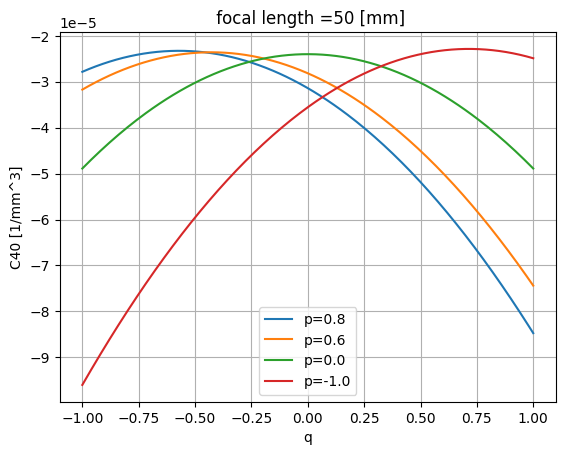

In [22]:
import numpy as np
import matplotlib.pyplot as plt


def Compute_C40_vsq(q,f,RI,p):
  C40value = np.zeros((q.size,2))
  i=0
  for qvalue in q:
    Csph    = C40(f,RI,p,qvalue)
    C40value[i,0] = qvalue
    C40value[i,1] = Csph
    i = i + 1
  return C40value
###################################
pupil   = 6  # mm

f       = 50 ## mm
RI = 1.5

Numq = 200
q       = np.linspace(-1,1,Numq)

Sprime  = 1.2*f ## mm
p       = 1 - 2*f/Sprime
Vprime = [10*f,5*f,2*f,f]
L_res = []

for Sprime in Vprime:
  p          = 1 - 2*f/Sprime
  C40_valori = Compute_C40_vsq(q,f,RI,p)
  L_res.append([p,Sprime,C40_valori])

NS = len(L_res)
plt.figure()
for k in range(NS):
  A  = np.array(L_res[k][2])
  pv = L_res[k][0]
  plt.plot(A[:,0],A[:,1],label='p='+str(pv))

plt.xlabel('q')
plt.ylabel('C40 [1/mm^3]')
plt.grid()
plt.legend()
plt.title(' focal length =' + str(np.round(f,2))+' [mm]')



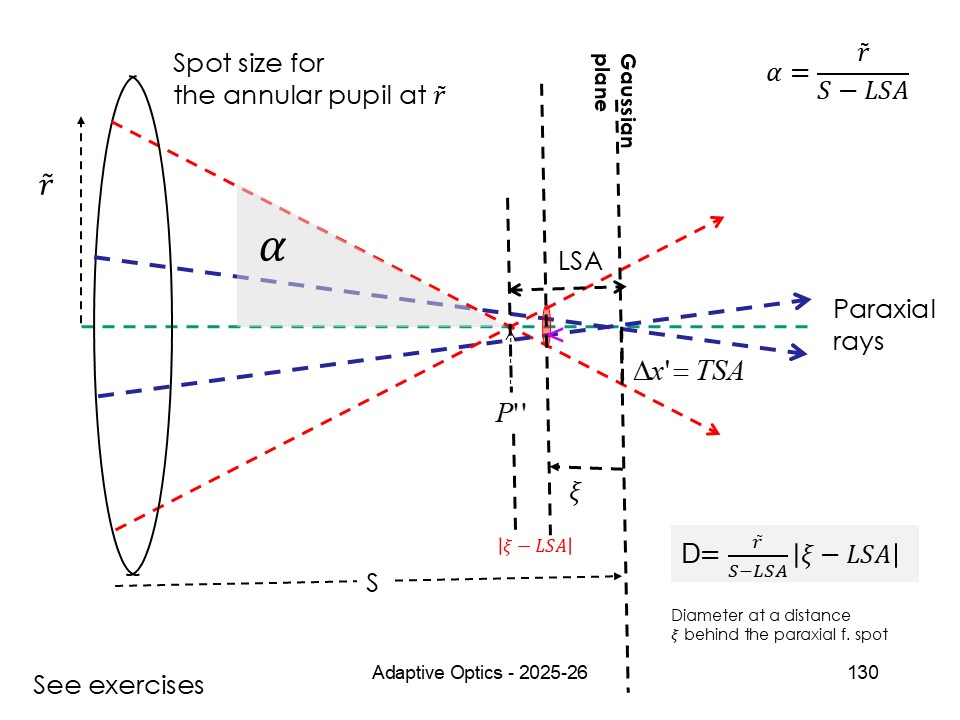

Sprime =  75.0
mininum diameter= 0.1311 mm
minum confusion position= 45.35991598221891 50 -4.64008401778109


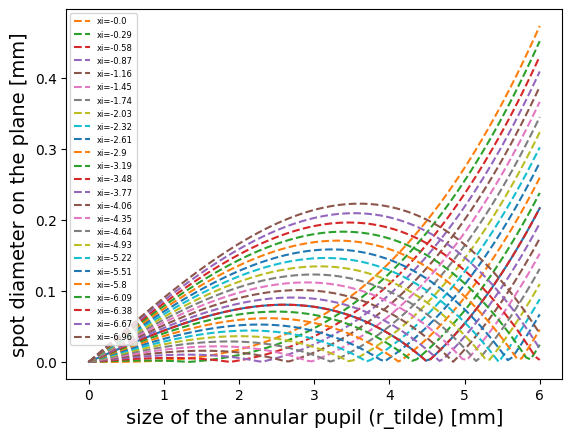

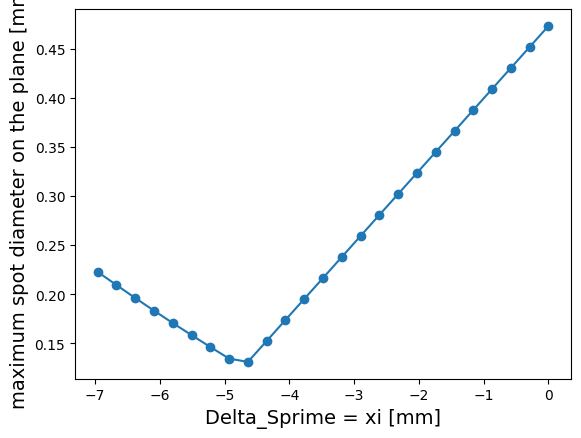

In [28]:
############### least confusion circle
'''
###  the diameter of the spot on a plane at the distance csi from the Gaussian plane
coming from an annular pupil at radial coordinate x.
we take the LSA in absoloute value, by reversing the optical axis
the same for the variable csi. it is positive going towards the lens from the Gaussian plane
The computation is done according to the figure above.

'''
Sprime = 1.5*f
print ('Sprime = ',Sprime)
tsa_max     = TSA(Csph,Sprime,pupil,RI)
lsa_max     = LSA(tsa_max,Sprime,pupil)

def DiamSpot(x,S,csi,lsa):
    return x/(S-lsa)*np.abs(csi-lsa)

csi = lsa_max*0.5 ##mm
yD  = DiamSpot(x,Sprime,csi,yl)
plt.plot(x,yD)
CSIv        = lsa_max * np.linspace(0,1,25)
#plt.plot(x,DiamSpot(x,Sprime,csi,yl))

Dmax = []
for csi in CSIv:
    DiamV       = DiamSpot(x,Sprime,csi,yl)
    plt.plot(x,DiamV,'--',label='xi='+str(round(csi,3)))
    #print (csi,round(DiamV[DiamV.argmax()],4))
    Dmax.append(round(DiamV[DiamV.argmax()],4))  ### find the maximum diamter for each value of xi
plt.legend(prop={'size':6})
plt.ylabel('spot diameter on the plane [mm]',fontsize=14)
plt.xlabel('size of the annular pupil (r_tilde) [mm]',fontsize=14)

DmaxV   = np.array(Dmax)
plt.figure()
plt.plot(CSIv,DmaxV,'-o')
plt.ylabel('maximum spot diameter on the plane [mm]',fontsize=14)
plt.xlabel('Delta_Sprime = xi [mm]',fontsize=14)

print ('mininum diameter=',DmaxV.min(),'mm')
print ('minum confusion position=',f+CSIv[DmaxV.argmin()],f,CSIv[DmaxV.argmin()])


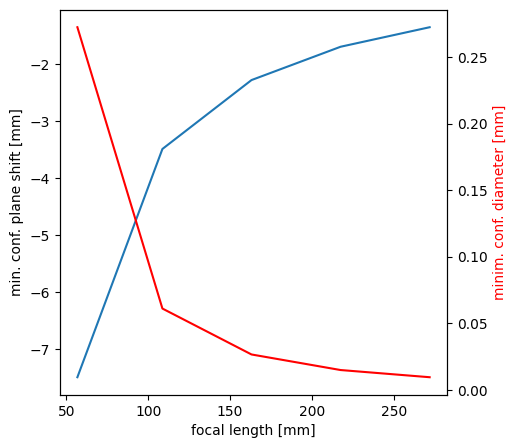

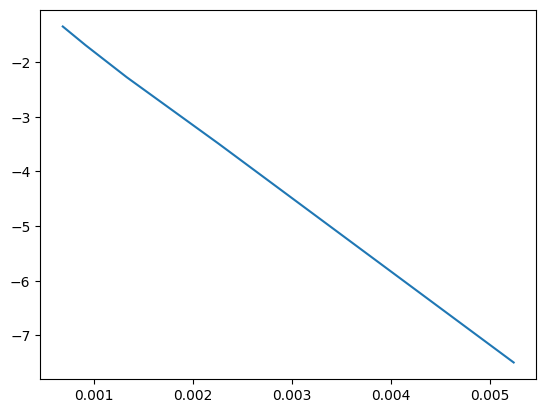

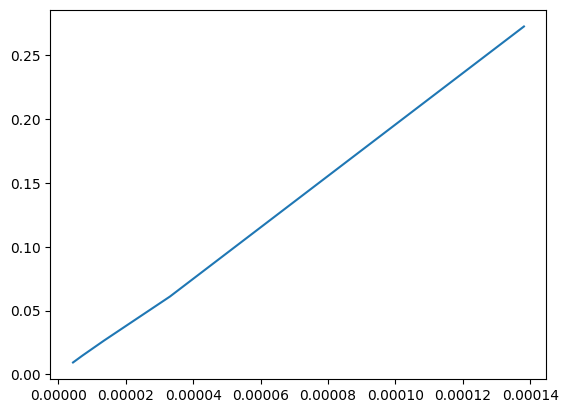

In [29]:
Diam_min    = np.array([0.2724,0.061,0.0265,0.0148,0.0094])
Shift       = np.array([-7.4946154228590265,-3.486,-2.276,-1.691,-1.348])
posMinConf  = np.array([49.3235663953228 ,110.1506376 , 168.182,225.58,282.74] )



foc         = np.array([56.818 ,108.6956522,163.0434783,217.3913043,271.7391304])
F,A = plt.subplots(figsize=(5,5))
A1 = A.twinx()

A.plot(foc,Shift)
A.set_ylabel('min. conf. plane shift [mm]')
A1.plot(foc,Diam_min,c='red')
A1.set_ylabel('minim. conf. diameter [mm]',c='red')
A.set_xlabel('focal length [mm]')

plt.figure()
plt.plot(1./foc**1.3,Shift)
plt.figure()
plt.plot(1./foc**2.2,Diam_min)






[0.05280017 0.0276     0.0184     0.0138     0.01104   ]
[0.0057765  0.01105072 0.01657609 0.02210145 0.02762681]


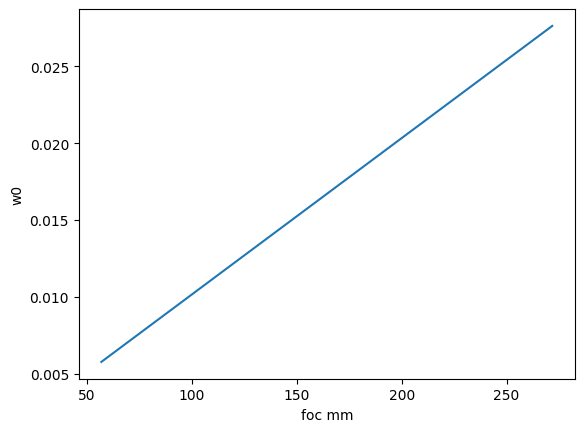

In [ ]:
NA = pupil/2/foc
wav = 0.5e-3
w0 = 0.61 * wav/NA
print (NA)
plt.figure()
plt.plot(foc,w0)
plt.xlabel('foc mm')
plt.ylabel('w0')
print (w0)
